## MLP Try # 1

---

#### Parameters in the data: 

| Parameter | Range (approx) | Physical meaning |
|---|---|---|
| `m1` [M☉] | ~1,000 – 900,000 M☉ | Mass of the central **Intermediate Mass Black Hole (IMBH)**. The dominant body in the system. Sets the orbital timescales, the ISCO frequency $f_\mathrm{ISCO} = c^3 / (6^{3/2} \pi G m_1)$ where the inspiral terminates, and the physical size of the DM spike $r_\mathrm{sp}$ via equation (3). Since $f_\mathrm{ISCO} \propto 1/m_1$, a heavier IMBH means a lower termination frequency — this is why LISA (sensitive at $10^{-3}$–$10^{-2}$ Hz) is the target detector, not LIGO. |
| `m2` [M☉] | ~3 – 100 M☉ | Mass of the **inspiraling compact object** (stellar-mass black hole or neutron star). Determines how strongly the small body feels dynamical friction — a heavier $m_2$ loses orbital energy to friction faster (note $\dot{E}_\mathrm{DF} \propto m_2^2$), shortening the inspiral and increasing the accumulated dephasing. The ratio $q = m_2/m_1 \ll 1$ is what makes this an *extreme* mass ratio inspiral. |
| `gsp` ($\gamma_\mathrm{sp}$) | ~2.0 – 2.5 | **Power-law slope of the DM density spike**: $\rho_\mathrm{DM}(r) \propto (r_\mathrm{sp}/r)^{\gamma_\mathrm{sp}}$. A steeper slope means DM is more concentrated near the center, producing stronger dynamical friction and more dephasing as the compact object spirals inward. The benchmark value $\gamma_\mathrm{sp} = 7/3 \approx 2.33$ arises from $\gamma_\mathrm{sp} = (9 - 2\alpha)/(4 - \alpha)$ when an IMBH grows adiabatically at the center of an NFW halo with inner slope $\alpha = 1$. The range 2.0–2.5 brackets realistic astrophysical scenarios. |
| `rhosp` [M☉/pc³] | ~10 – ~10,000 M☉/pc³ | **Density normalization of the DM spike** at the reference radius $r_\mathrm{sp}$. Controls the overall amplitude of the DM distribution — a higher $\rho_\mathrm{sp}$ means more DM mass at every radius, more dynamical friction, and a larger dephasing signal. Together with $\gamma_\mathrm{sp}$, it fully specifies the initial density profile $\rho_\mathrm{DM}(r) = \rho_\mathrm{sp}(r_\mathrm{sp}/r)^{\gamma_\mathrm{sp}}$ used by the simulator. |
| `fGW` [Hz] | ~$10^{-3}$ – ~5 Hz | **Gravitational wave frequency** at which the dephasing is evaluated. Related to orbital separation $r$ by $f_\mathrm{GW} = (1/\pi)\sqrt{Gm_1/r^3}$, so it directly tracks the inspiral progress — low frequency means the compact object is still far from the IMBH, high frequency means it is close to merger. Each sample has its own frequency grid of 200 points running up to $f_\mathrm{ISCO} \propto 1/m_1$. This is the 5th input to the MLP. |
| `dPh` [rad] | ~$10^{-4}$ – ~$10^{6}$ rad | **The dephasing** $\Delta\Phi(f)$ — the quantity the MLP predicts. It is the accumulated difference in GW phase between a system with a DM spike and an identical vacuum system, computed as $\Delta\Phi(f) = 2\pi \int_{f}^{f_\mathrm{ISCO}} \frac{f'}{(\dot{f}^\mathrm{vac})^2} \delta\dot{f}(f')\, df'$. Large values at low frequencies reflect a long history of DM-accelerated inspiral; the value always falls to zero at $f_\mathrm{ISCO}$ by construction. The ~10 orders of magnitude dynamic range across the dataset is why we train on $\log_{10}(\Delta\Phi)$. |

#### The general idea: 
- each training set is a 5-tuple $\rightarrow$ scalar: ```(log10(m1), log10(m2), gsp, log10(rhosp), log10(f))  →  log10(ΔΦ)```
- from 10,000 files x 200 frequency points, this means 2,000,000 training pairs: a simple regression problem (no sequence modeling needed yet)



#### Key preprocessing decisions: 
- why log-transform inputs and output? 
    - ```m1```: ranges from 1e3 to 9e5 (factor 900x); linear scale would make NN spend most time on large-m1 systems
    - ```rhosp```: same vibes as m1
    - ```f```: 4 O.O.M. 
    - ```dph``` spans 10 O.O.M. -- log turns this into much smoother regression target (~-4 to 6) 
    - ```gsp``` is already narrow range (only ~2.0 - 2.5) so can stay linear

#### Train/val/test split:
- Split at the file level (i.e., by sample index), not at the row level. If you split row-by-row, the same physical system's nearby frequency points could appear in both train and test — that would leak information and give falsely optimistic results.

#### Normalization:
- After log-transforming, apply standard zero-mean, unit-variance scaling on the training set, then apply the same transform to val/test.

#### Architecture: 
Simple starting MLP: 
```Input (5) → Linear(5,64) → ReLU → Linear(64,128) → ReLU → Linear(128,64) → ReLU → Linear(64,1)```

- ```Linear(5, 64)```: Takes 5 numbers and produces 64. Each of the 64 outputs is weighted sum of all 5 inputs, plus a bias term. So this layer is 5x64 + 64 = 384 learnable parameters. At the start, these weights are random; by end of training they've learned something like "m1 and f together seem to matter a lot for dephasing". 

- ```ReLU```: Applied element-wise to those 64 numbers: replace any negative value with 0, leaves positive values unchanged. No learnable parameters. Without this (or similar nonlinearity), stacking linear layers would just collapse into a single linear layer, and you could never fit a curved surface. 

- ```Linear(64, 128)```: Takes those 64 numbers (some now zeroed out by the ReLU) and produces 128 numbers. The network is widening here -- it's building up a richer internal representation. (64x128 + 128 = 8320 parameters) 

- ```ReLU```: same as before

- ```Linear(128, 64)```: Now narrows back down from 128 → 64. The network is compressing. Has to summarize what it learned into fewer numbers. 128x64 + 64 = 8256 parameters

- ```ReLU```: same as before

- ```Linear(64, 1)```: final compression to single number -- predicted $log10(\Delta\Phi)$. 64x1 + 1 = 65 parameters. 

So the whole network has roughly 17,000 parameters total, all trained by backpropagation to minimize MSE between predicted and true log10(dph). Hourglass shape (5 → 64 → 128 → 64 → 1) is a common pattern: expand first to give network room to find structure in the inputs, then compress back down to the answer. 

Loss: MSE on ```log10(dph)``` -- equivalent to relative error in log-space, which makes sense given dynamic range. 

In [1]:
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
import torch


In [2]:
# for on my own laptop, setting number of cores, or also 
torch.set_num_threads(8)

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")
print(f"Number of threads: {torch.get_num_threads()}")


Using device: mps
Number of threads: 8


In [3]:
torch.manual_seed(42)

### Step 1: Data loading — parser + building values for the flat (params, f) → $\Delta\Phi$ table

In [23]:
def parse_sample(filepath):
    """
    Parses a single dephasing_sample_N.csv file.
    Returns:
        params: dict with m1, m2, gsp, rhosp (as floats)
        freqs:  numpy array of GW frequencies [Hz]
        dph:    numpy array of dephasing values [rad]
    """
    # Row 0 has the params encoded in column names, row 1 has fGW/dPh headers
    raw = pd.read_csv(filepath, skiprows=0)
    
    # Extract physical parameters from column name strings
    col_names = raw.columns.tolist()
    params = {}
    for col in col_names:
        if '=' in col:
            key, val = col.strip().split('=')
            params[key.strip()] = float(val.strip())
    # Skip row 0 (the fGW/dPh header row) and read actual data
    data = pd.read_csv(filepath, skiprows=1)
    freqs = data['fGW[Hz]'].values.astype(float)
    dph   = data['dPh[rad]'].values.astype(float)
    
    return params, freqs, dph


def load_all_samples(data_dir='data/'):
    """
    Loads all dephasing_sample_*.csv files and process using parse_sample.
    Returns a list of (params, freqs, dph) tuples, one per file.
    """
    filepaths = sorted(glob.glob(f'{data_dir}dephasing_sample_*.csv'))
    print(f"Found {len(filepaths)} files")
    
    all_samples = []
    for fp in filepaths:
        try:
            params, freqs, dph = parse_sample(fp)
            params['sample#'] = int(fp.split('_')[-1].split('.')[0])
            all_samples.append((params, freqs, dph))
        except Exception as e:
            print(f"  Warning: skipped {fp} — {e}")
    
    print(f"Successfully loaded {len(all_samples)} samples")
    return all_samples


# --- Run it ---
all_samples = load_all_samples('data/')

# Sanity check on the first sample
params, freqs, dph = all_samples[0]
print("\nFirst sample:")
print("  params:", params)
print("  freq range: [{:.4e}, {:.4e}] Hz".format(freqs.min(), freqs.max()))
print("  dph range:  [{:.4e}, {:.4e}] rad".format(dph.min(), dph.max()))
print("  num points:", len(freqs))

Found 10000 files
Successfully loaded 10000 samples

First sample:
  params: {'m1': 101268.01, 'm2': 8.197, 'gsp': 2.138, 'rhosp': 2904.897, 'sample#': 1}
  freq range: [3.2420e-03, 4.3422e-02] Hz
  dph range:  [0.0000e+00, 2.5176e+03] rad
  num points: 200


Example: ```parse_sample``` on one individual file, and plot: 

{'m1': 33114.307, 'm2': 8.44, 'gsp': 2.306, 'rhosp': 36.793}


Text(0, 0.5, '$\\Delta\\Phi$ [Hz]')

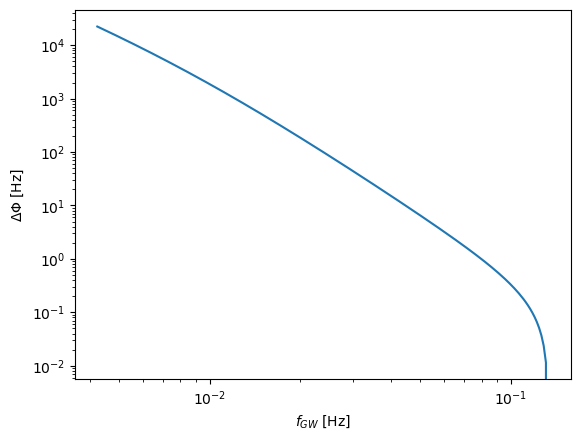

In [6]:
params_5, freqs_5, dph_5 = parse_sample('data/dephasing_sample_5.csv')
print(params_5)

plt.loglog(freqs_5, dph_5)
plt.xlabel('$f_{GW}$ [Hz]')
plt.ylabel('$\Delta\Phi$ [Hz]')

### Step 2. Dataset & DataLoader — PyTorch Dataset class, train/val/test split by file

#### On the "flattening" aspect of this step: 

(*extend the VSCode window to look at this properly*)

### Before flattening — the raw structure

After Step 1, `all_samples` is a nested structure. Each element is one physical system:

```python
all_samples[0]  →  params = {m1: 101268, m2: 8.2, gsp: 2.14, rhosp: 2904}
                   freqs  = [0.00324, 0.00328, 0.00333, ..., 0.04342]  # 200 numbers
                   dph    = [2517.6,  2405.1,  2297.4,  ..., 0.0    ]  # 200 numbers

all_samples[1]  →  params = {m1: 617264, m2: 86.7, gsp: 2.17, rhosp: 1558}
                   freqs  = [0.00110, 0.00111, ..., 0.01025]           # 200 numbers
                   dph    = [30.3,    29.1,    ..., 0.0    ]           # 200 numbers

# ... (10,000 of these)
```

It is a list of lists essentially — 10,000 systems, each containing 200 points.
This is a natural way to store simulation output, but PyTorch's `Dataset` cannot
work with this structure. It needs to be able to say *"give me example number 47,832"*
and get back a single input vector and a single target value instantly.

---

### After flattening — what the MLP actually sees

Each individual $(f, \Delta\Phi)$ pair becomes its own independent training example,
with the four physical parameters **repeated** alongside it:

```python
row 0:       [log10(101268), log10(8.2), 2.14, log10(2904), log10(0.00324)]  →  log10(2517.6)
row 1:       [log10(101268), log10(8.2), 2.14, log10(2904), log10(0.00328)]  →  log10(2405.1)
# ...
row 199:     [log10(101268), log10(8.2), 2.14, log10(2904), log10(0.04342)]  →  log10(0.0)  # skipped (d <= 0)
row 200:     [log10(617264), log10(86.7), 2.17, log10(1558), log10(0.00110)] →  log10(30.3)
# ...
row ~2,000,000: last point of last sample
```

This is what **"flat"** means — instead of a nested hierarchy of files and points,
you have one big 2D table where every row is a self-contained example. The shape
ends up being roughly $(2{,}000{,}000 \times 5)$ for $X$ and $(2{,}000{,}000,)$ for $y$.

---

### Why is this necessary?

The MLP has no concept of "files" or "sequences". It just takes a vector of 5 numbers
and outputs 1 number. It does not know or care that rows 0–198 all came from the same
physical system — and that is fine, because the question it is answering is simply:

> *Given these 5 values of $(m_1, m_2, \gamma_\mathrm{sp}, \rho_\mathrm{sp}, f)$, what is $\Delta\Phi$?*

Each row is a complete, independent answer to that question. The flattening is what
turns your simulation output into a format that matches the question the MLP is being
trained to answer.

---

#### Actual Code for Step 2: 

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
# Dataset is a PyTorch abstract class — you subclass it and tell it what your data looks like. 
# DataLoader wraps a Dataset and handles batching, shuffling, and feeding data into the training loop automatically.

class DephasingDataset(Dataset):

    # building the flat table
    def __init__(self, all_samples): 
        self.X = []
        self.y = []

        # ----- core flattening step. ------
        # each of the 10,000 files has 200 (f, Δφ) pairs. 
        # loop over every file and every point inside it, turning the nested structure into one big flat list of individual training examples. 
        # 'if d <= 0' skips the final point of each sample where dephasing is exactly 0 — we can't take log10(0).
        for params, freqs, dph in all_samples:

            # grabbing metadata 
            m1     = params['m1'] 
            m2     = params['m2']
            gsp    = params['gsp']
            rhosp  = params['rhosp']
            # grabbing freq vs. dph data
            for f, d in zip(freqs, dph):
                if d <= 0:
                    continue

            # ----- building the input vector -----
            # This is the log-transform. Four of the five inputs span orders of magnitude and are log-transformed. 
            # gsp lives in a narrow range (~2.0–2.5) so it stays linear. 
            # The target y is also log-transformed because dephasing spans ~10 orders of magnitude.

                # build vector w/ transforms
                x = [
                    np.log10(m1), # log
                    np.log10(m2), # log
                    gsp, # stays linear because narrow range
                    np.log10(rhosp), # log
                    np.log10(f) # log
                ]
                self.X.append(x) # append transformed params (small x to big X) 
                self.y.append(np.log10(d)) # append the dphi

        # ----- converting to tensors: ----- 
        # PyTorch operates on tensors, not numpy arrays or Python lists. float32 (32-bit floating point) 
        # is standard for neural network training — float64 would double the memory usage for no meaningful gain in this context.
        
        # self.X starts as a Python list of lists, where each inner list has 5 elements. 
        # After torch.tensor(self.X) it becomes a 2D tensor of shape (N, 5), where N is the number of valid 
        # (non-zero dephasing) rows — roughly 2,000,000 if all 10,000 files loaded cleanly with 199 usable points each.
        self.X = torch.tensor(self.X, dtype=torch.float32) 
        # self.y starts as a flat Python list of scalars. After torch.tensor(self.y) it becomes a 1D tensor of shape (N,).
        self.y = torch.tensor(self.y, dtype=torch.float32)

        # ----- normalization -----
        # dim=0 means compute the mean/std across all rows, separately for each of the 5 columns. After this, each input feature 
        # has mean 0 and standard deviation 1. This matters a lot for training — without it, features on very different 
        # scales (log10(m1) ~ 3–6, gsp ~ 2–2.5) would cause the gradient updates to be imbalanced, making the network hard to train. 
        # We store X_mean and X_std on the training dataset so we can apply the exact same transform to val and test.
        self.X_mean = self.X.mean(dim=0)
        self.X_std  = self.X.std(dim=0)
        self.X = (self.X - self.X_mean) / self.X_std # normalization step

# ----- defining required PyTorch things -----
    def __len__(self): # tells DataLoader how many examples exist 
        return len(self.X)

    def __getitem__(self, idx): # tells it how to retrieve example number [idx] (here, just return input row & corr. target value)
        return self.X[idx], self.y[idx]



# ------------- SPLITTING -------------
# --- Split by sample index, not by row --- 
n_samples  = len(all_samples) # should be 10,000
# NEXT TWO LINES: Decides how many systems go into each split — 
# 7,000 for training, 1,500 for validation, and the remaining 1,500 implicitly go to test. 
# (Don't need to compute n_test explicitly because we'll just take whatever indices are left over.)
# The int() is because x 0.7 gives a float (7000.0), list slicing requires integers.
n_train    = int(0.7 * n_samples) 
n_val      = int(0.15 * n_samples)

# Indices step: Generates a random permutation of the integers 0 to 9,999 — like shuffling 
# a deck of 10,000 cards. This is the critical randomisation step. Without it, you would always put 
# the first 7,000 files into training, which could be biased if the files happen to be ordered by some parameter 
# (e.g. if sample_1 through sample_7000 all had low m1 values, your training set would never see heavy systems).
indices    = torch.randperm(n_samples) # randomization

# next three lines: 
# Slices that shuffled deck into three non-overlapping groups. Because indices is already randomised, these three 
# groups are random and disjoint — no system appears in more than one split. The test slice uses no end index, so it 
# automatically takes everything remaining after train and val.
train_idx  = indices[:n_train] # slice shuffled deck with pre-calculated integer length n_train
val_idx    = indices[n_train : n_train + n_val] # take everything from n_train to n_train + n_val (7000 + 1500)
test_idx   = indices[n_train + n_val:] # take everything from last index as the test

# next three lines: 
# Uses those index groups to actually pull the corresponding (params, freqs, dph) tuples out of all_samples. 
# Each is a list comprehension — for every index i in train_idx, grab all_samples[i]. The result is three separate nested lists 
# of systems, which then each get passed into DephasingDataset(...) where the flattening happens. This is the step that guarantees 
# all 200 frequency points from one physical system land in the same split — because we are selecting whole systems, not individual rows.
train_samples = [all_samples[i] for i in train_idx]
val_samples   = [all_samples[i] for i in val_idx]
test_samples  = [all_samples[i] for i in test_idx]




# APPLY CLASS
# --- Build datasets ---
# Each of these calls the __init__ method of DephasingDataset on one of the three nested lists of systems. This is where the actual flattening, 
# log-transforming, and normalisation all happen — three times, once per split. After these three lines you have three independent flat tensors (X, y), each 
# normalised using their own mean and std. 
train_dataset = DephasingDataset(train_samples) 
val_dataset   = DephasingDataset(val_samples)
test_dataset  = DephasingDataset(test_samples)

# --- Apply train statistics to val and test ---
# This block exists to fix a subtle but important mistake that the previous step introduced. When we built val_dataset and test_dataset, the __init__ method 
# normalised them using their own mean and std. That is wrong, for the following reason: in a real deployment, you would never have access to the statistics 
# of future or unseen data. ***The only statistics you are allowed to use are the ones computed from the training set***. So we need to undo the val/test normalisation 
# and redo it using the training set's statistics.

val_dataset.X  = (val_dataset.X * val_dataset.X_std + val_dataset.X_mean) # this UNDOES the normalization that __init__ applied to val_dataset (norm X = (X - mean)/std), do reverse) 
val_dataset.X  = (val_dataset.X - train_dataset.X_mean) / train_dataset.X_std # this re-normalizes val_dataset.X using training set's mean and std instead 

test_dataset.X = (test_dataset.X * test_dataset.X_std + test_dataset.X_mean) # same thing as above, undoes normalization 
test_dataset.X = (test_dataset.X - train_dataset.X_mean) / train_dataset.X_std # re-normalizes using training 

# --- DataLoaders ---
# train_loader line: Wraps train_dataset in a DataLoader. The DataLoader is what training loop will actually iterate over — it handles slicing the dataset into batches automatically. 
# batch_size=1024 means each iteration hands you 1024 rows at once as a tensor of shape (1024, 5) for X and (1024,) for y. 
# shuffle=True means at the start of every epoch the DataLoader randomly reorders all the rows before batching them up, so the network sees examples in a different order each epoch, 
# preventing it from accidentally learning patterns in the ordering.
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)  
# val_loader line: Same batch size, but shuffle=False. There is no reason to shuffle validation data — we are just running forward passes through the network to compute a loss, not 
# updating any weights, so order does not matter. Keeping it unshuffled also makes debugging easier since the same example will always appear in the same position.
val_loader   = DataLoader(val_dataset,   batch_size=1024, shuffle=False)
# test_loader line: Same as val — no shuffling needed. The test loader is used only once at the very end, after training is fully complete, to get a final unbiased estimate of how well 
# the model performs on data it has never seen in any form.
test_loader  = DataLoader(test_dataset,  batch_size=1024, shuffle=False)

# --- Sanity checks ---
print(f"Total training rows:   {len(train_dataset)}")
print(f"Total val rows:        {len(val_dataset)}")
print(f"Total test rows:       {len(test_dataset)}")

# for final line here (within sanity check)
# iter(train_loader): Turns the DataLoader into a Python iterator — an object that you can repeatedly ask "give me the next thing". The DataLoader itself is not an iterator by default, 
# it is an iterable, meaning it knows how to produce batches but does not start doing so until you explicitly ask it to.

# next(...): Asks that iterator for exactly one batch — the first one. The DataLoader internally shuffles the dataset (because shuffle=True), 
# slices out the first 1024 rows, and returns them as two tensors.
# X_batch, y_batch = ...: Unpacks those two tensors into separate variables. The DataLoader returns them as a tuple (X, y) because that is what __getitem__ returns — a pair.
# So X_batch ends up with shape (1024, 5) and y_batch with shape (1024,).
X_batch, y_batch = next(iter(train_loader)) 
print(f"\nOne batch  — X shape: {X_batch.shape}, y shape: {y_batch.shape}")
print(f"X sample (first row): {X_batch[0]}")
print(f"y sample (first row): {y_batch[0]:.4f}  (log10 of dephasing in rad)")

Total training rows:   1393000
Total val rows:        298500
Total test rows:       298500

One batch  — X shape: torch.Size([1024, 5]), y shape: torch.Size([1024])
X sample (first row): tensor([-0.3198,  1.6429, -0.8645, -0.2630, -0.8750])
y sample (first row): 1.1538  (log10 of dephasing in rad)


#### *Why a class here and not just a function?* 

A class is a blueprint for an object that bundles together both data and the methods that operate on that data. The reason to use a class here rather than a plain function comes down to what PyTorch's ```DataLoader``` requires. The ```DataLoader``` expects to receive something that behaves like a ```Dataset``` — meaning it can ask "how many examples do you have?" and "give me example number N" at any point during training. A plain function runs once and returns something, but cannot be queried repeatedly in that way. The class stays alive in memory throughout training, and the ```DataLoader``` keeps reaching into it batch after batch via ```__getitem__```.

#### *Why only use training statistics, and why undo-then-redo?*

This is one of the most important principles in machine learning, called **avoiding data leakage**.

The mathematical motivation is this. When you normalise a feature $x$ using mean $\mu$ and standard deviation $\sigma$:

$$\tilde{x} = \frac{x - \mu}{\sigma}$$

the values of $\mu$ and $\sigma$ encode **information about the dataset they were computed from**. If you compute $\mu_\text{val}$ and $\sigma_\text{val}$ from the validation set and use them to normalise it, you have allowed information from the validation set to influence how that data is represented to the model. This is a form of **leakage** — the model is indirectly seeing something about the distribution of the validation data before it is ever evaluated on it.

More concretely: suppose your validation set happened by chance to contain unusually massive systems, so $\mu_\text{val}(\log_{10} m_1)$ is higher than $\mu_\text{train}(\log_{10} m_1)$. Normalising val with its own mean would shift those values downward to look "typical", hiding the fact that they are actually out of distribution relative to training. The model's val loss would look better than it really is, giving you a falsely optimistic picture of generalisation.

The correct rule is:

$$\tilde{x}_\text{val} = \frac{x_\text{val} - \mu_\text{train}}{\sigma_\text{train}}$$

This way, val and test examples are scaled in exactly the same coordinate system the model learned from during training. If a val example is genuinely unusual relative to the training distribution, that shows up as a large normalised value — and the model's performance on it honestly reflects how well it generalises.

As for why we undo-then-redo rather than just not normalising in the first place: it is purely a code architecture issue. The `__init__` method always normalises — that is its job, and we want it to always do that consistently. It would be messier to add a special flag saying "normalise with these external statistics instead of your own". The undo-then-redo is a clean two-line correction applied after the fact:

$$x_\text{val}^\text{raw} = \tilde{x}_\text{val} \cdot \sigma_\text{val} + \mu_\text{val}$$

$$\tilde{x}_\text{val}^\text{correct} = \frac{x_\text{val}^\text{raw} - \mu_\text{train}}{\sigma_\text{train}}$$

which leaves the `DephasingDataset` class itself simple and self-contained.

### Step 3: Model — MLP definition

In [ ]:
import torch
import torch.nn as nn

class DephasingMLP(nn.Module):
    # nn.Module is PyTorch's base class for all neural networks.
    # Every custom network you build must inherit from it.

    def __init__(self):
        # __init__ defines the LAYERS of the network .
        super().__init__()
        # super().__init__() calls nn.Module's own __init__, which sets up
        # all of PyTorch's internal machinery (parameter tracking, etc).
        # must always call this first, before defining any layers.

        self.network = nn.Sequential(
            # container that chains layers together in order

            nn.Linear(5, 64),
            # layer 1: takes the 5 input features and produces 64 numbers
            # internally, its computing: output = X @ W.T + b
            # where W has shape (64, 5) and b has shape (64,)
            # Total learnable parameters here: 5*64 + 64 = 384
            # weights W and biases b are what are updated during training 

            nn.ReLU(),
            # appling ReLU element-wise to the 64 numbers: f(x) = max(0, x)

            nn.Linear(64, 128),
            # layer 2: takes the 64 numbers, expands to 128...network is widening
            # Parameters: 64*128 + 128 = 8,320

            nn.ReLU(),
            # Same same

            nn.Linear(128, 64),
            # layer 3: compressesing back from 128 to 64
            # network now being forced to summarise what it learned
            # in the wider layer into a more compact representation
            # Parameters: 128*64 + 64 = 8,256.

            nn.ReLU(),
            # Same yada yada.

            nn.Linear(64, 1)
            # last layer: compresses from 64 down to single number —
            # the predicted log10(delta_phi) for this input.
            # no ReLU here -- output can be any real number, positive
            # or negative, since log10(delta_phi) ranges from about -4 to 6.
            # Parameters: 64*1 + 1 = 65.
        )

    def forward(self, x):
        # forward() defines what happens when you actually pass data through
        # the network. PyTorch calls this automatically when you do model(x)
        # x has shape (batch_size, 5) — one row per example in the batch
        return self.network(x)
        # passes x through every layer in nn.Sequential in order and
        # returns the final output, shape (batch_size, 1)


# --- Instantiate model --- 
# DON'T FORGET MAKE SURE TO RE-INITIATE THE MODEL BEFORE RUNNING THE LOOP CELL BELOW !!!!!
model = DephasingMLP()
# creates ONE instance of network, random weights initialized

# --- Define loss function ---
loss_fn = nn.MSELoss()
# MSE: for each example, computes (predicted - true)^2, then averages over the batch
# working in log10 space: this penalises relative errors in dephasing rather than absolute ones

# --- Define optimiser ---
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)
# RECALL: Adam is an adaptive gradient descent algorithm 
# keeps running estimate of the mean, variance of each parameter's gradient,
# and uses those to scale the update for each parameter individually
# model.parameters() hands Adam all the learnable weights and biases
# in the network so it knows what to update
# lr=1e-3 (learning rate = 0.001) controls the step size per update

# --- Sanity check ---
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {total_params}")
# p.numel() returns the number of elements in each parameter tensor
# summing over all params gives the total parameter count
# expect: 384 + 8320 + 8256 + 65 = 17,025

# --- Test a forward pass ---
X_batch, y_batch = next(iter(train_loader))
y_pred = model(X_batch)
print(f"\nInput shape:  {X_batch.shape}")   # (1024, 5)
print(f"Output shape: {y_pred.shape}")      # (1024, 1)
print(f"Sample prediction: {y_pred[0].item():.4f}  (log10 dephasing, untrained)")
print(f"Sample truth:      {y_batch[0].item():.4f}  (log10 dephasing)")
# At this point the weights are random so the prediction will be terrible.
# That is expected — this is just confirming the shapes are correct and
# data flows through the network without errors.

DephasingMLP(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total trainable parameters: 17025

Input shape:  torch.Size([1024, 5])
Output shape: torch.Size([1024, 1])
Sample prediction: 0.0610  (log10 dephasing, untrained)
Sample truth:      -0.6571  (log10 dephasing)


In [21]:
# dephasing MLP with dropout included

class DephasingMLP_Dropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(5, 64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)
    
model_drop = DephasingMLP_Dropout()
optimiser_drop = torch.optim.Adam(model_drop.parameters(), lr=1e-3)
print(model_drop)

DephasingMLP_Dropout(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)


Look at the dimensions of the input and output ^. Makes sense. 

% look at the explanation under "1. Does each training example...." and read/copy through all answers. these are good. It's good to think about what each batch is, each example, and how this compares to the resultant tensors. 

### Step 4: Training loop — with validation loss tracking

Epoch   1/50  |  Train loss: 0.1082  |  Val loss:   0.0042
Epoch   2/50  |  Train loss: 0.0032  |  Val loss:   0.0028
Epoch   3/50  |  Train loss: 0.0018  |  Val loss:   0.0020
Epoch   4/50  |  Train loss: 0.0012  |  Val loss:   0.0007
Epoch   5/50  |  Train loss: 0.0009  |  Val loss:   0.0009
Epoch   6/50  |  Train loss: 0.0008  |  Val loss:   0.0009
Epoch   7/50  |  Train loss: 0.0007  |  Val loss:   0.0007
Epoch   8/50  |  Train loss: 0.0006  |  Val loss:   0.0006
Epoch   9/50  |  Train loss: 0.0005  |  Val loss:   0.0006
Epoch  10/50  |  Train loss: 0.0005  |  Val loss:   0.0003
Epoch  11/50  |  Train loss: 0.0004  |  Val loss:   0.0007
Epoch  12/50  |  Train loss: 0.0004  |  Val loss:   0.0012
Epoch  13/50  |  Train loss: 0.0004  |  Val loss:   0.0004
Epoch  14/50  |  Train loss: 0.0003  |  Val loss:   0.0003
Epoch  15/50  |  Train loss: 0.0003  |  Val loss:   0.0002
Epoch  16/50  |  Train loss: 0.0003  |  Val loss:   0.0003
Epoch  17/50  |  Train loss: 0.0003  |  Val loss:   0.00

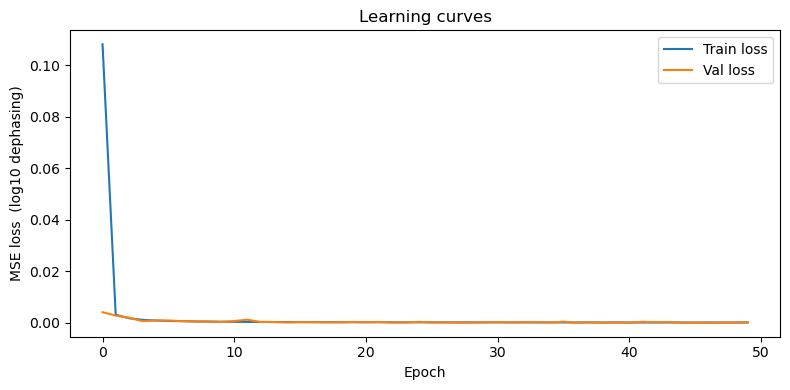

In [9]:

# --- Training configuration ---
N_EPOCHS = 50
# The number of full passes through the training data.
# 50 is a reasonable starting point — enough to see whether the
# model is learning, without committing to a very long run upfront.

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f"Training on: {device}") 
# PyTorch can run on CPU or GPU. This line checks whether a CUDA-capable
# GPU is available and sets the device accordingly. If you are on a laptop
# without a GPU, this will say 'cpu' and everything still works, just slower.

model = model.to(device) # physically moves it to the right memory
# Moves all the model's weight and bias tensors to the chosen device.
# If device is 'cuda', they now live in GPU memory. If 'cpu', no change.
# This must be done before any forward passes.

# --- Storage for tracking progress ---
train_losses = []
val_losses   = []
# Simple Python lists that we will append to after each epoch,
# so we can plot the learning curves afterwards.

# --- Training loop ---
for epoch in range(N_EPOCHS):

    # ------------------ Training phase ------------------
    model.train() 
    # Puts the model in training mode. This matters for layers like
    # Dropout or BatchNorm (which we don't have here, but it is good
    # practice to always call this at the start of the training phase).

    running_train_loss = 0.0
    # Accumulator for the total loss across all batches in this epoch.
    # We will divide by the number of batches at the end to get the mean.

    for X_batch, y_batch in train_loader:
        # Iterates over every batch in the training DataLoader.
        # Each iteration gives us X_batch of shape (1024, 5)
        # and y_batch of shape (1024,).

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        # Moves the batch tensors to the same device as the model.
        # If model is on GPU, data must also be on GPU — they must
        # always be on the same device or PyTorch will throw an error.

        optimiser.zero_grad() # STEP 1 of LOOP 
        # Clears the gradients from the previous batch.
        # PyTorch accumulates gradients by default (adds to whatever
        # is already stored). If you forget this, gradients from
        # previous batches pile up and corrupt the current update.

        y_pred = model(X_batch) # STEP 2 of LOOP
        # Forward pass: runs X_batch through all layers of the network.
        # Output shape is (1024, 1).

        loss = loss_fn(y_pred.squeeze(), y_batch) 
        # Computes MSE between predictions and true values. 
        # .squeeze() removes the trailing dimension of size 1 from y_pred, 
        # changing shape from (1024, 1) to (1024,) to match y_batch's shape. 
        # **** NOTING: loss.backward() needs to know what to differentiate. Loss is the single scalar number 
        # that summarizes how wrong the model is on this batch. 

        loss.backward() # STEP 3 of LOOP 
        # Backward pass: computes the gradient of the loss with respect
        # to every learnable parameter in the network, using the chain rule.
        # After this call, every parameter p has p.grad filled in.

        optimiser.step() # STEP 4 of LOOP 
        # Uses the gradients computed by loss.backward() to UPDATE 
        # all the weights and biases by one Adam step.

        running_train_loss += loss.item()
        # .item() converts the loss from a single-element tensor to a
        # plain Python float so we can accumulate it normally.
        # **** NOTING: the var "loss" at this point is a tensor containing single scalar - MSE averaged over 
        # the 1024 examples in that batch, item just extracts it as a Python float (you can't accumulate PyTorch tensors
        # in a Python variable cleanly)
        # in a 
        # 

    mean_train_loss = running_train_loss / len(train_loader)
    # Divides total accumulated loss by the number of batches in one epoch 
    # to get the **AVERAGE LOSS PER BATCH FOR THIS EPOCH** 
    train_losses.append(mean_train_loss)

    # ------------------ Validation phase ------------------
    model.eval()
    # Puts the model in evaluation mode — the counterpart to model.train().
    # Again, matters more for Dropout/BatchNorm, but always good practice.

    running_val_loss = 0.0

    with torch.no_grad():
        # Disables gradient computation entirely for everything inside
        # this block. During validation we are *NOT UPDATING WEIGHTS*, 
        # so we do not need gradients. This saves memory and speeds
        # up the forward passes by roughly 2x. 

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            loss   = loss_fn(y_pred.squeeze(), y_batch)
            running_val_loss += loss.item()
        # note in this loop: same pattern as training lop, with three critical missing: 
            # no optimizer.zero_grad(): not updating weights, no grads to clear 
            # no loss.backward(): we don't compute gradients 
            # no optimiser.step(): we are not changing any parameters
        # we are purely doing forward passes and measuring how wrong predictions are, without 
        # touching the model at all. Just observing how model performs on data it hasn't trained on


    mean_val_loss = running_val_loss / len(val_loader)
    val_losses.append(mean_val_loss) # only append one value per epoch

    # ---- Progress report ----
    print(f"Epoch {epoch+1:>3}/{N_EPOCHS}  |  "
          f"Train loss: {mean_train_loss:.4f}  |  "
          f"Val loss:   {mean_val_loss:.4f}")
    # epoch+1 because epoch is zero-indexed (starts at 0).
    # :>3 right-aligns the epoch number in a field of width 3,
    # keeping the printout tidy as numbers grow from 1 to 50.

# --- Plot learning curves ---
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses,   label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE loss  (log10 dephasing)')
plt.title('Learning curves')
plt.legend()
plt.tight_layout()
plt.show()
# Plotting both curves on the same axes lets you immediately see:
# (1) whether the model is learning at all (loss decreasing)
# (2) whether it is overfitting (train loss keeps falling but val loss
#     plateaus or rises)
# (3) whether more epochs would help (both still decreasing at epoch 50)

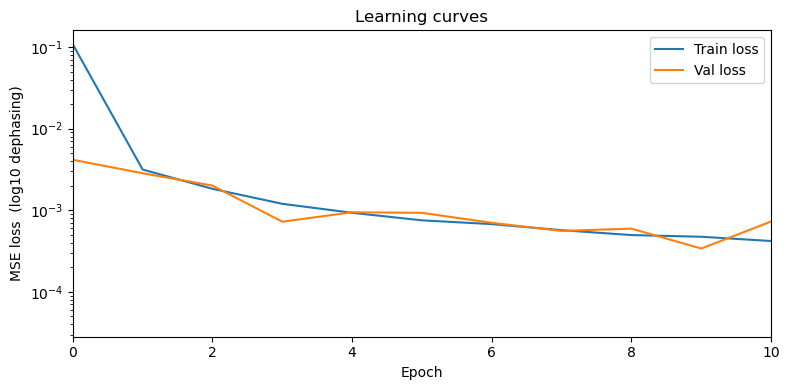

In [18]:
# --- Plot learning curves ---
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses,   label='Val loss')
plt.yscale('log')
plt.xlim(0, 10)

plt.xlabel('Epoch')
plt.ylabel('MSE loss  (log10 dephasing)')
plt.title('Learning curves')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
print("y min:  ", train_dataset.y.min().item())
print("y max:  ", train_dataset.y.max().item())
print("y mean: ", train_dataset.y.mean().item())
print("y std:  ", train_dataset.y.std().item())
print("total training rows:", len(train_dataset))

y min:   -7.975366592407227
y max:   6.361166477203369
y mean:  1.134103775024414
y std:   2.0931992530822754
total training rows: 1393000


In [12]:
model.eval()
with torch.no_grad():
    X_batch, y_batch = next(iter(val_loader))
    X_batch = X_batch.to(device)
    y_pred  = model(X_batch).squeeze().cpu()

print("True values (first 10): ", y_batch[:10])
print("Pred values (first 10): ", y_pred[:10])

True values (first 10):  tensor([4.4986, 4.4813, 4.4640, 4.4466, 4.4292, 4.4118, 4.3943, 4.3768, 4.3592,
        4.3416])
Pred values (first 10):  tensor([4.5116, 4.4948, 4.4781, 4.4613, 4.4443, 4.4263, 4.4083, 4.3903, 4.3723,
        4.3543])


In [11]:
# how linear is the problem? try a linear model (no hidden layers)
import torch
import torch.nn as nn

linear_model = nn.Linear(5, 1).to(device)
linear_optim = torch.optim.Adam(linear_model.parameters(), lr=1e-3)
loss_fn_test = nn.MSELoss()

# train for just 3 epochs
for epoch in range(3):
    linear_model.train()
    running = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        linear_optim.zero_grad()
        y_pred = linear_model(X_batch).squeeze()
        loss = loss_fn_test(y_pred, y_batch)
        loss.backward()
        linear_optim.step()
        running += loss.item()
    print(f"Epoch {epoch+1} | Linear model train loss: {running/len(train_loader):.4f}")

Epoch 1 | Linear model train loss: 2.6080
Epoch 2 | Linear model train loss: 0.4789
Epoch 3 | Linear model train loss: 0.2037


### Step 5: Evaluation — plot predicted vs true Δφ on test samples

Test set size: 298500 points
Test MSE loss: 0.0003


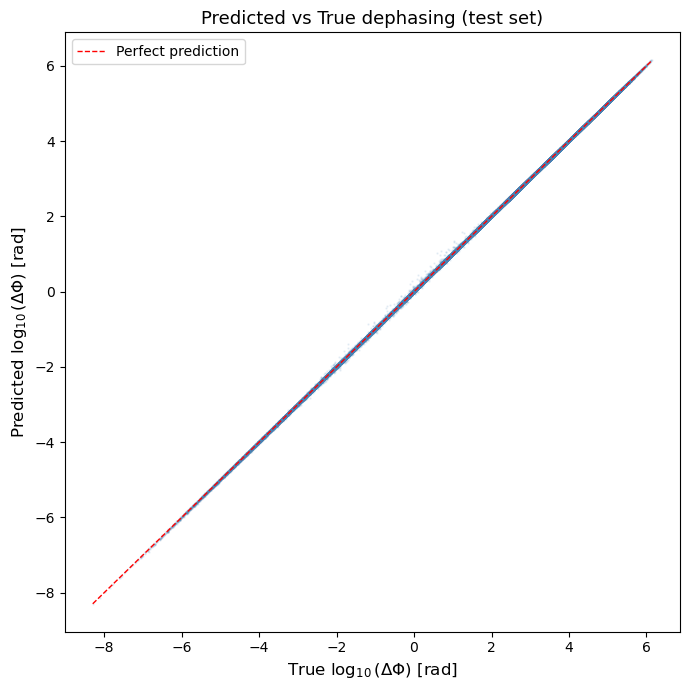

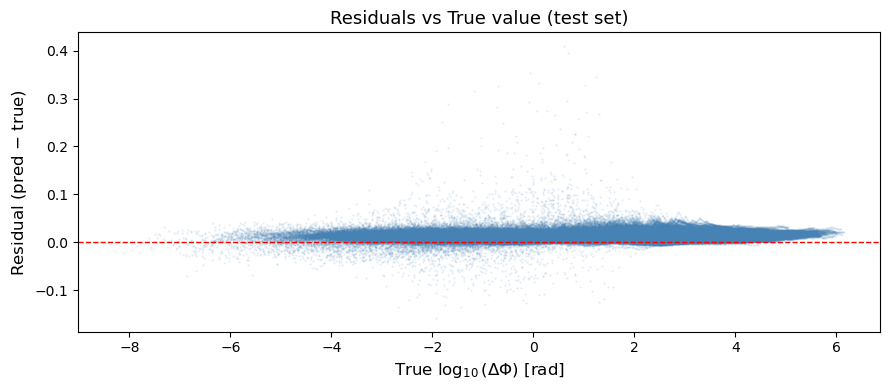

Mean residual:   0.0139   (bias — should be near 0)
Std of residuals: 0.0092  (spread — lower is better)


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# ---- 1. Collect all test predictions ----
model.eval()
# Set model to evaluation mode 
# Always do this before any evaluation or inference

all_preds = []
all_trues = []

with torch.no_grad():
    # Disable gradient tracking for the entire evaluation block
    # We are only doing forward passes, so no gradients are needed
    # This saves memory and speeds things up

    for X_batch, y_batch in test_loader:
        # Iterate over every batch in the test set
        # test_loader has shuffle=False, so batches always come
        # in the same order — important for reproducibility

        X_batch = X_batch.to(device)
        # Move input batch to the same device as the model (MPS/CPU/CUDA).

        y_pred = model(X_batch).squeeze().cpu()
        # Forward pass: get predictions for this batch.
        # .squeeze() removes the trailing size-1 dimension: (1024,1) → (1024,)
        # .cpu() moves the tensor back to CPU memory so numpy can work with it.
        # (numpy cannot operate on MPS or CUDA tensors directly)

        all_preds.append(y_pred)
        all_trues.append(y_batch)
        # Append this batch's predictions and true values to the lists.
        # y_batch is already on CPU (DataLoader always returns CPU tensors).

all_preds = torch.cat(all_preds).numpy()
all_trues = torch.cat(all_trues).numpy()
# torch.cat() concatenates the list of batch tensors into one single tensor.
# e.g. a list of ~292 tensors each of shape (1024,) becomes one tensor of
# shape (~298500,). .numpy() then converts to a numpy array for plotting.

print(f"Test set size: {len(all_preds)} points")
print(f"Test MSE loss: {np.mean((all_preds - all_trues)**2):.4f}")
# Quick sanity check — recompute MSE manually to confirm it matches
# what the training loop was reporting for validation loss.
# np.mean((pred - true)^2) is exactly what nn.MSELoss computes.


# ---- 2. Predicted vs True scatter plot ----
fig, ax = plt.subplots(figsize=(7, 7))
# Creates a square figure — important for a predicted vs true plot
# because both axes have the same units and range.

ax.scatter(all_trues, all_preds, s=0.5, alpha=0.1, color='steelblue')
# Scatter plot with true values on x-axis and predicted on y-axis.
# s=0.5: very small marker size because we have ~300,000 points —
# large markers would completely obscure each other.
# alpha=0.1: 90% transparent, so overlapping points show up as
# denser regions rather than a solid blob.

lims = [all_trues.min(), all_trues.max()]
ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
# Draws the y=x line (perfect prediction line) in red dashes.
# If the model were perfect, every point would lie exactly on this line.
# Deviations above the line = model overpredicts; below = underpredicts.

ax.set_xlabel(r'True $\log_{10}(\Delta\Phi)$ [rad]', fontsize=12)
ax.set_ylabel(r'Predicted $\log_{10}(\Delta\Phi)$ [rad]', fontsize=12)
ax.set_title('Predicted vs True dephasing (test set)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


# ---- 3. Residuals plot ----
residuals = all_preds - all_trues
# Residual for each point: positive means model overpredicted,
# negative means model underpredicted.

fig, ax = plt.subplots(figsize=(9, 4))

ax.scatter(all_trues, residuals, s=0.5, alpha=0.1, color='steelblue')
# Plot residuals (y-axis) against true values (x-axis).
# This is more informative than the scatter plot above for spotting
# where the model struggles — any systematic curve or fan shape
# in this plot reveals structure the model has not captured.

ax.axhline(0, color='red', linestyle='--', linewidth=1)
# Draws a horizontal line at residual = 0 (perfect prediction).
# Points above this line: model overpredicted.
# Points below this line: model underpredicted.

ax.set_xlabel(r'True $\log_{10}(\Delta\Phi)$ [rad]', fontsize=12)
ax.set_ylabel(r'Residual (pred $-$ true)', fontsize=12)
ax.set_title('Residuals vs True value (test set)', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Mean residual:   {residuals.mean():.4f}   (bias — should be near 0)")
print(f"Std of residuals: {residuals.std():.4f}  (spread — lower is better)")
# Mean residual (bias): if nonzero, the model is systematically over or
# underpredicting on average across the whole test set.
# Std of residuals: the typical size of a prediction error.
# Together these give a more interpretable summary than raw MSE.

In [17]:
print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final val loss:   {val_losses[-1]:.4f}")
print(f"Gap:              {val_losses[-1] - train_losses[-1]:.4f}")

Final train loss: 0.0002
Final val loss:   0.0003
Gap:              0.0001


In [15]:
params.keys()

dict_keys(['m1', 'm2', 'gsp', 'rhosp'])

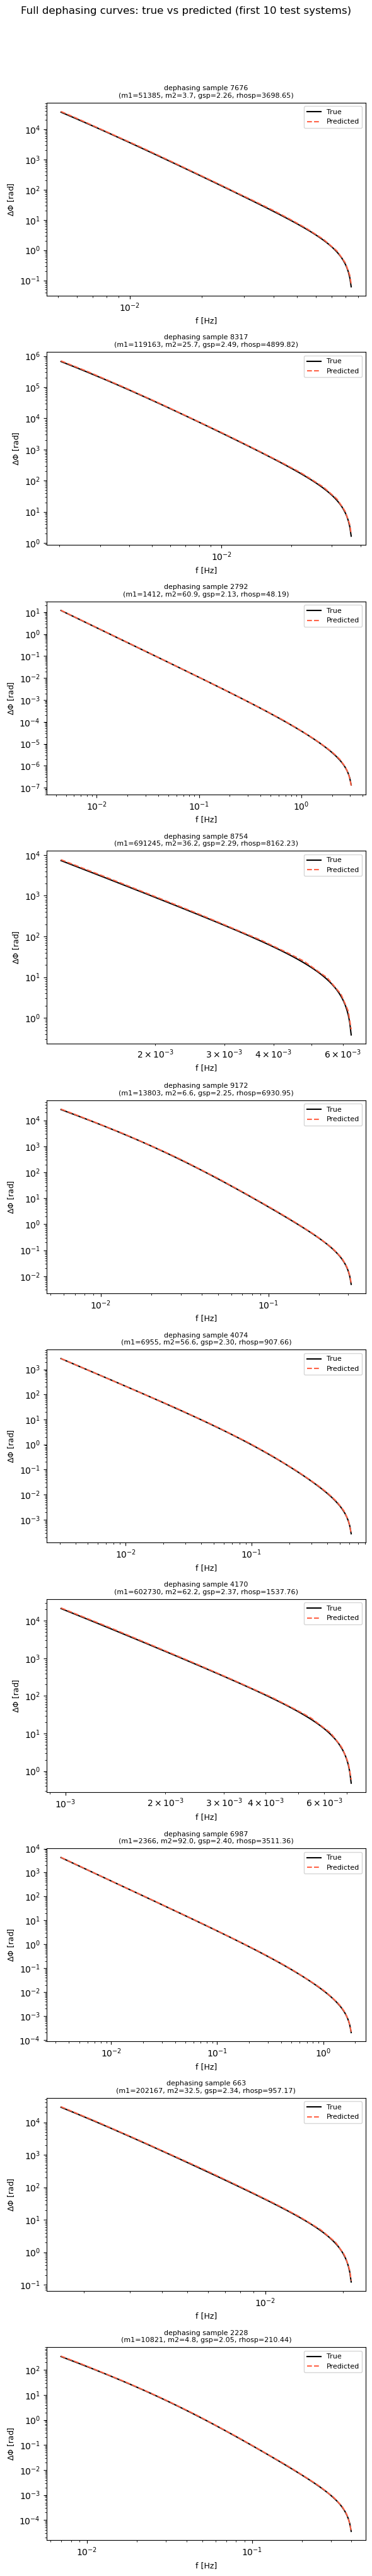

In [ ]:

# ---- 4. Reconstruct and plot full dephasing curves for a few test systems ----
# The scatter plots above treat every (f, dph) point independently.
# Here we reconstruct the full dephasing curve for a handful of
# test systems and overlay model predictions, to see how well the
# model captures the shape of the curve end-to-end.

n_systems_to_plot = 10
# How many test systems to visualise. Keep small for readability.

fig, axes = plt.subplots(n_systems_to_plot, 1, figsize=(6, 4*n_systems_to_plot),
                          sharex=False, sharey=False)
# Creates a row of n subplots sharing the same y-axis scale,
# one per system. sharey=True means zooming or scaling one panel
# affects all panels — useful for visual comparison.

for i, ax in enumerate(axes):
    params, freqs, dph = test_samples[i]
    # Pull the i-th test system's raw data directly from test_samples
    # (the nested list from Step 1, before flattening).
    # This gives us access to the full frequency grid and true dephasing.

    # --- build the input tensor for this system ---
    valid_mask = dph > 0
    # Boolean mask: True for every frequency point with nonzero dephasing.
    # We need this to match exactly what went into the dataset — we skipped
    # d <= 0 rows during flattening, so we must skip them here too.

    freqs_valid = freqs[valid_mask]
    dph_valid   = dph[valid_mask]
    # Apply the mask to get only the usable frequency points and
    # their corresponding true dephasing values.

    m1    = params['m1']
    m2    = params['m2']
    gsp   = params['gsp']
    rhosp = params['rhosp']
    sample_num = params['sample#']
    # Extract the four physical parameters for this system.

    X_system = torch.tensor([
        [np.log10(m1), np.log10(m2), gsp, np.log10(rhosp), np.log10(f)]
        for f in freqs_valid
    ], dtype=torch.float32)
    # Build the input matrix for this system: one row per frequency point,
    # with the same log-transforms applied as during training.
    # Shape: (n_valid_points, 5)

    X_system = (X_system - train_dataset.X_mean.cpu()) / train_dataset.X_std.cpu()
    # Apply the TRAINING normalisation to this system's inputs.
    # Critical: must use train_dataset.X_mean and X_std, not recompute.
    # train_dataset tensors are on CPU so we call .cpu() to be safe.

    with torch.no_grad():
        X_system = X_system.to(device)
        y_system_pred = model(X_system).squeeze().cpu().numpy()
    # Forward pass for the full system: move to device, run through model,
    # bring back to CPU as a numpy array.
    # y_system_pred is log10(predicted dephasing) for each frequency point.

    # --- plot ---
    ax.plot(freqs_valid, dph_valid,
            color='black', linewidth=1.5, label='True')
    # Plot the true dephasing curve in black.
    # Note: dph_valid is in LINEAR space (raw radians), not log10.

    ax.plot(freqs_valid, 10**y_system_pred,
            color='tomato', linewidth=1.5, linestyle='--', label='Predicted')
    # Plot the predicted dephasing curve in red dashes.
    # 10**y_system_pred converts from log10 space back to linear radians,
    # so both curves are on the same scale.

    ax.set_xscale('log')
    ax.set_yscale('log')
    # Both axes on log scale — this is the natural space for these curves,
    # matching the plot of the original 40 samples you showed earlier.

    ax.set_title(f"dephasing sample {sample_num:.0f}\n(m1={m1:.0f}, m2={m2:.1f}, gsp={gsp:.2f}, rhosp={rhosp:.2f})", fontsize=8)
    # Label each panel with the physical parameters of that system
    # so you can see whether errors correlate with any particular parameter.

    ax.set_xlabel('f [Hz]', fontsize=9)
    ax.set_ylabel(r'$\Delta\Phi$ [rad]', fontsize=9)
    ax.legend(fontsize=8)
    # Only label the y-axis and show legend on the leftmost panel
    # to avoid visual clutter across all 5 panels.

plt.suptitle('Full dephasing curves: true vs predicted (10 random systems)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Epoch   1/50  |  Train loss: 0.2284  |  Val loss:   0.0946
Epoch   2/50  |  Train loss: 0.0438  |  Val loss:   0.1736
Epoch   3/50  |  Train loss: 0.0235  |  Val loss:   0.1797
Epoch   4/50  |  Train loss: 0.0165  |  Val loss:   0.1977
Epoch   5/50  |  Train loss: 0.0127  |  Val loss:   0.2105
Epoch   6/50  |  Train loss: 0.0105  |  Val loss:   0.2043
Epoch   7/50  |  Train loss: 0.0090  |  Val loss:   0.2347
Epoch   8/50  |  Train loss: 0.0080  |  Val loss:   0.2419
Epoch   9/50  |  Train loss: 0.0072  |  Val loss:   0.2660
Epoch  10/50  |  Train loss: 0.0067  |  Val loss:   0.2593
Epoch  11/50  |  Train loss: 0.0062  |  Val loss:   0.2863
Epoch  12/50  |  Train loss: 0.0059  |  Val loss:   0.2643
Epoch  13/50  |  Train loss: 0.0056  |  Val loss:   0.2697
Epoch  14/50  |  Train loss: 0.0053  |  Val loss:   0.2757
Epoch  15/50  |  Train loss: 0.0051  |  Val loss:   0.2733
Epoch  16/50  |  Train loss: 0.0049  |  Val loss:   0.2805
Epoch  17/50  |  Train loss: 0.0047  |  Val loss:   0.30

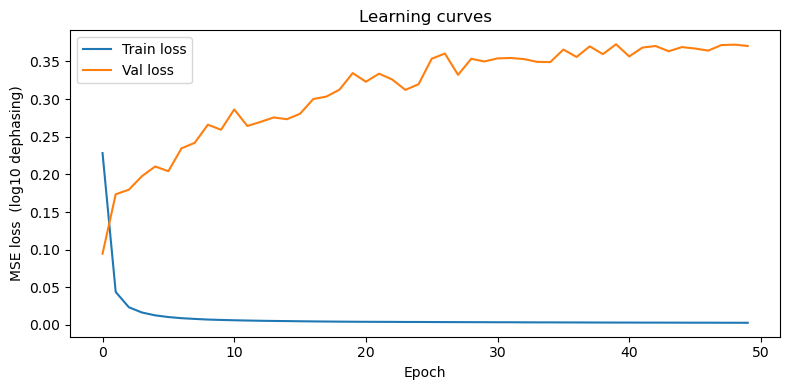

In [22]:
### WITH DROPOUT!!!


# --- Training configuration ---
N_EPOCHS = 50


model_drop = model_drop.to(device)

# --- Storage for tracking progress ---
train_losses = []
val_losses   = []
# Simple Python lists that we will append to after each epoch,
# so we can plot the learning curves afterwards.

# --- Training loop ---
for epoch in range(N_EPOCHS):

    # ------------------ Training phase ------------------
    model_drop.train() 
    # Puts the model in training mode

    running_train_loss = 0.0
    # Accumulator for the total loss across all batches in this epoch

    for X_batch, y_batch in train_loader:
        # Each iteration gives us X_batch of shape (1024, 5)
        # and y_batch of shape (1024,).

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        # Moves the batch tensors to the same device as the model

        optimiser_drop.zero_grad() # STEP 1 of LOOP 
        # Clears the gradients from the previous batch

        y_pred = model_drop(X_batch) # STEP 2 of LOOP
        # Forward pass: runs X_batch through all layers of the network.
        # Output shape is (1024, 1)

        loss = loss_fn(y_pred.squeeze(), y_batch) 
        # Computes MSE between predictions and true values. 
        # .squeeze() removes the trailing dimension of size 1 from y_pred, 
        # changing shape from (1024, 1) to (1024,) to match y_batch's shape. 
        # **** NOTING: loss.backward() needs to know what to differentiate. Loss is the single scalar number 
        # that summarizes how wrong the model is on this batch. 

        loss.backward() # STEP 3 of LOOP 
        # Backward pass: computes the gradient of the loss with respect
        # to every learnable parameter in the network, using the chain rule.
        # After this call, every parameter p has p.grad filled in.

        optimiser_drop.step() # STEP 4 of LOOP 
        # Uses the gradients computed by loss.backward() to UPDATE 
        # all the weights and biases by one Adam step.

        running_train_loss += loss.item()
        # .item() converts the loss from a single-element tensor to a
        # plain Python float so we can accumulate it normally.
        # **** NOTING: the var "loss" at this point is a tensor containing single scalar - MSE averaged over 
        # the 1024 examples in that batch, item just extracts it as a Python float (you can't accumulate PyTorch tensors
        # in a Python variable cleanly)
        # in a 
        # 

    mean_train_loss = running_train_loss / len(train_loader)
    # Divides total accumulated loss by the number of batches in one epoch 
    # to get the **AVERAGE LOSS PER BATCH FOR THIS EPOCH** 
    train_losses.append(mean_train_loss)

    # ------------------ Validation phase ------------------
    model_drop.eval()
    # Puts the model in evaluation mode — the counterpart to model.train().
    # Again, matters more for Dropout/BatchNorm, but always good practice.

    running_val_loss = 0.0

    with torch.no_grad():
        # Disables gradient computation entirely for everything inside
        # this block. During validation we are *NOT UPDATING WEIGHTS*, 
        # so we do not need gradients. This saves memory and speeds
        # up the forward passes by roughly 2x. 

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model_drop(X_batch)
            loss   = loss_fn(y_pred.squeeze(), y_batch)
            running_val_loss += loss.item()
        # note in this loop: same pattern as training lop, with three critical missing: 
            # no optimizer.zero_grad(): not updating weights, no grads to clear 
            # no loss.backward(): we don't compute gradients 
            # no optimiser.step(): we are not changing any parameters
        # we are purely doing forward passes and measuring how wrong predictions are, without 
        # touching the model at all. Just observing how model performs on data it hasn't trained on


    mean_val_loss = running_val_loss / len(val_loader)
    val_losses.append(mean_val_loss) # only append one value per epoch

    # ---- Progress report ----
    print(f"Epoch {epoch+1:>3}/{N_EPOCHS}  |  "
          f"Train loss: {mean_train_loss:.4f}  |  "
          f"Val loss:   {mean_val_loss:.4f}")
    # epoch+1 because epoch is zero-indexed (starts at 0).
    # :>3 right-aligns the epoch number in a field of width 3,
    # keeping the printout tidy as numbers grow from 1 to 50.

# --- Plot learning curves ---
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses,   label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE loss  (log10 dephasing)')
plt.title('Learning curves')
plt.legend()
plt.tight_layout()
plt.show()
# Plotting both curves on the same axes lets you immediately see:
# (1) whether the model is learning at all (loss decreasing)
# (2) whether it is overfitting (train loss keeps falling but val loss
#     plateaus or rises)
# (3) whether more epochs would help (both still decreasing at epoch 50)